In [1]:
import gpt as g
import sys, os
import numpy as np

from scipy.linalg import expm
import time
import matplotlib.pyplot as plt
from gpt.qcd.gauge.smear import local_stout  
from gpt.ad import reverse as rad
from gpt.qcd.gauge.smear.differentiable import dft_diffeomorphism
import time

SharedMemoryNone: SharedMemoryAllocate 1073741824 GPU implementation 
0SharedMemoryNone:  SharedMemoryNone.cc acceleratorAllocDevice 1073741824bytes at 0x308000000 for comms buffers 

__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
__|_ |  |  |  |  |  |  |  |  |  |  |  | _|__
__|_                                    _|__
__|_   GGGG    RRRR    III    DDDD      _|__
__|_  G        R   R    I     D   D     _|__
__|_  G        R   R    I     D    D    _|__
__|_  G  GG    RRRR     I     D    D    _|__
__|_  G   G    R  R     I     D   D     _|__
__|_   GGGG    R   R   III    DDDD      _|__
__|_                                    _|__
__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
  |  |  |  |  |  |  |  |  |  |  |  |  |  |  


Copyright (C) 2015 Peter Boyle, Azusa Yamaguchi, Guido Cossu, Antonin Portelli and other authors

This program is free software; you can redistribute it and/or modify
it under the term

In [23]:
def trace_U(U):                                                      
    return sum(v for v in sum(u[:].real for u in g.eval(g.trace(U)))) / (4 * size**4 ) / 3.

In [2]:
size = 4
grid = g.grid([size, size], g.double)
rng = g.random("t")

U = g.qcd.gauge.unit(grid)
rng.normal_element(U)


GPT :       2.072055 s : Initializing gpt.random(t,vectorized_ranlux24_389_64) took 0.00110984 s


[lattice(ot_matrix_su_n_fundamental_group(3),double),
 lattice(ot_matrix_su_n_fundamental_group(3),double)]

In [3]:
# conjugate momenta
U_mom = g.group.cartesian(U)

action_gauge_mom = g.qcd.scalar.action.mass_term()
action_gauge = g.qcd.gauge.action.wilson(10.0)

metro = g.algorithms.markov.metropolis(rng)
inv = g.algorithms.inverter
sympl = g.algorithms.integrator.symplectic

log = sympl.log()

pure_gauge = True


In [4]:
def hamiltonian(draw):
    if draw:
        rng.normal_element(U_mom)
        
        s = action_gauge(U)

        g.message("Gluonic action", s)
        g.message("Mom action", action_gauge_mom(U_mom))
        h = s + action_gauge_mom(U_mom)

    else:
        
        s = action_gauge(U)
        g.message("Gluonic action", s)
        g.message("Mom action", action_gauge_mom(U_mom))
        
        h = s + action_gauge_mom(U_mom)
    return h, s


In [5]:
hamiltonian(True)

GPT :      85.039883 s : Gluonic action 161.6109447593405
GPT :      85.041799 s : Mom action 140.68066316570028


(np.float64(302.2916079250408), np.float64(161.6109447593405))

In [6]:
def gauge_force():
    x = log(lambda: action_gauge.gradient(U, U), "gauge")()
    #g.message("first level force complete")
    return x
    
#def gauge_force222():
#    return gauge_force() + log_det_force()

In [7]:
iq = sympl.update_q(
    U, log(lambda: action_gauge_mom.gradient(U_mom, U_mom), "gauge_mom")
)

ip_gauge = sympl.update_p(U_mom, gauge_force)

mdint = sympl.leap_frog(20, ip_gauge, iq)


g.message(f"Integration scheme:\n{mdint}")



GPT :      86.788811 s : Integration scheme:
                       : leap_frog(20, P, Q)
                       :   P(0.025, 0)
                       :   Q(0.05, 0)
                       :   P(0.05, 0)
                       :   Q(0.05, 0)
                       :   P(0.05, 0)
                       :   Q(0.05, 0)
                       :   P(0.05, 0)
                       :   Q(0.05, 0)
                       :   P(0.05, 0)
                       :   Q(0.05, 0)
                       :   P(0.05, 0)
                       :   Q(0.05, 0)
                       :   P(0.05, 0)
                       :   Q(0.05, 0)
                       :   P(0.05, 0)
                       :   Q(0.05, 0)
                       :   P(0.05, 0)
                       :   Q(0.05, 0)
                       :   P(0.05, 0)
                       :   Q(0.05, 0)
                       :   P(0.05, 0)
                       :   Q(0.05, 0)
                       :   P(0.05, 0)
                       :   Q(0.05, 

In [30]:
no_accept_reject = False

def hmc(tau):
    accrej = metro(U)
    g.message("After metro")

    h0, s0 = hamiltonian(True)
    
    mdint(tau)

    g.message("After mdint(tau)")
    h1, s1 = hamiltonian(False)
    g.message("After H(false)")
    
    if no_accept_reject:
        return [True, s1 - s0, h1 - h0]
    else:
        return [accrej(h1, h0), s1 - s0, h1 - h0]
   

In [34]:
accept, total = 0, 0
plaq_measurements = []
for it in range(50):
    #pure_gauge = it < 10
    no_accept_reject = it < 10
    g.message(pure_gauge, no_accept_reject)

    a, dS, dH = hmc(1.)
    accept += a
    total += 1


    #Uft = U
    #for s in reversed(sm):
    #    Uft = s(Uft)
        
    plaq = g.qcd.gauge.plaquette(U)
    plaq_measurements.append(plaq)
    #plaqft = g.qcd.gauge.plaquette(Uft)
    g.message(f"HMC plaq = {plaq}, dS = {dS}, dH = {dH}, acceptance = {accept/total}")
    g.message(f"Timing:\n{log.time}")
    g.message(f"TRAJECTORY NUMBER {it}")


GPT :    4240.674364 s : True True
GPT :    4240.674899 s : After metro
GPT :    4240.679433 s : Gluonic action 8.124425253656007
GPT :    4240.680011 s : Mom action 32.473222276007604
GPT :    4240.839293 s : After mdint(tau)
GPT :    4240.839855 s : Gluonic action 10.177448302453517
GPT :    4240.840485 s : Mom action 30.41258429033492
GPT :    4240.841067 s : After H(false)
GPT :    4240.841487 s : HMC plaq = 0.7455637924386621, dS = 2.0530230487975096, dH = -0.007614936875178557, acceptance = 1.0
GPT :    4240.841680 s : Timing:
                       : gauge                1.13e+00 s (=  69.75 %); time/s = 1.59e-03/1.24e-02/2.56e-03 (min/max/avg)
                       : norm                 4.85e-01 s (=  29.93 %); time/s = 2.97e-04/1.50e-03/5.63e-04 (min/max/avg)
                       : gauge_mom            5.16e-03 s (=   0.32 %); time/s = 7.87e-06/1.19e-04/1.23e-05 (min/max/avg)
GPT :    4240.841857 s : TRAJECTORY NUMBER 0
GPT :    4240.842026 s : True True
GPT :    4240.8423

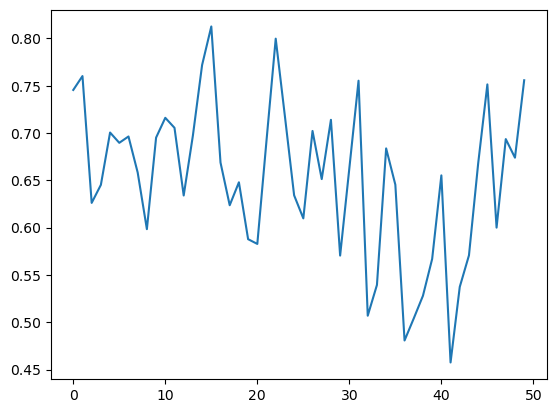

In [35]:
plt.plot(plaq_measurements)

In [36]:
meas = np.array(plaq_measurements)

print(f"Mean plaq = {np.mean(meas)}, std = {np.std(meas)}")

Mean plaq = 0.6518590475779267, std = 0.08209223082295358
